## **Anomaly Detection : Deep Learning Focused**

In [1]:
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed

In [ ]:
df = pd.read_csv('Data/GOOG_historical.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2004-08-19 00:00:00-04:00,2.470383,2.570680,2.370580,2.478783,897427216,0.0,0.0
1,2004-08-20 00:00:00-04:00,2.495333,2.694694,2.482735,2.675672,458857488,0.0,0.0
2,2004-08-23 00:00:00-04:00,2.735949,2.803390,2.693953,2.702599,366857939,0.0,0.0
3,2004-08-24 00:00:00-04:00,2.748054,2.756947,2.558575,2.590690,306396159,0.0,0.0
4,2004-08-25 00:00:00-04:00,2.592914,2.668014,2.566233,2.618606,184645512,0.0,0.0


In [3]:
df = df[['Date', 'Close']]

In [4]:
# Summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5438 entries, 0 to 5437
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5438 non-null   object 
 1   Close   5438 non-null   float64
dtypes: float64(1), object(1)
memory usage: 85.1+ KB


In [5]:
df.describe()

,Close
count,5438.000000
mean,58.048134
std,63.706192
min,2.470629
25%,13.267005
50%,29.359839
75%,81.766703
max,344.657196


In [6]:
# min and max time period

df['Date'].min(), df['Date'].max()

('2004-08-19 00:00:00-04:00', '2026-03-31 00:00:00-04:00')

# Lets visualize the data

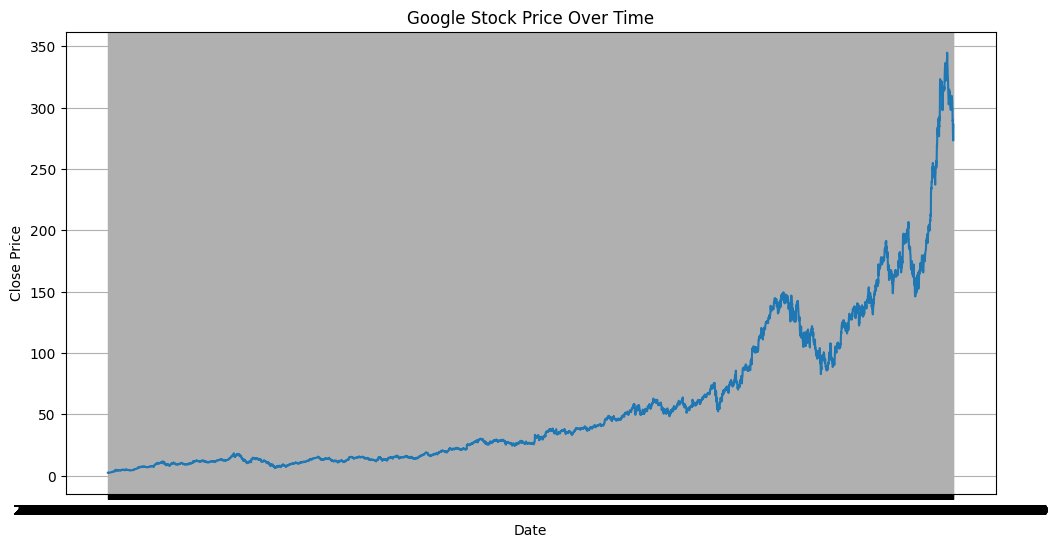

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'])
plt.title('Google Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid()
plt.show()

In [8]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], name='Close price'))
fig.update_layout(showlegend=True, title='Google Inc. Stock Price 2004-2026')
fig.show(renderer='browser')

## Data Preprocessing

In [9]:
train = df.loc[df['Date'] <= '2022-12-24']
test = df.loc[df['Date'] > '2022-12-24']
train.shape, test.shape

((4621, 2), (817, 2))

In [10]:
# Data Scaling

scaler = StandardScaler()
scaler = scaler.fit(np.array(train['Close']).reshape(-1, 1))

train['Close'] = scaler.transform(np.array(train['Close']).reshape(-1,1))
test['Close'] = scaler.transform(np.array(test['Close']).reshape(-1,1))

C:\Users\samsung\AppData\Local\Temp\ipykernel_9864\665933885.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Close'] = scaler.transform(np.array(train['Close']).reshape(-1,1))
C:\Users\samsung\AppData\Local\Temp\ipykernel_9864\665933885.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Close'] = scaler.transform(np.array(test['Close']).reshape(-1,1))


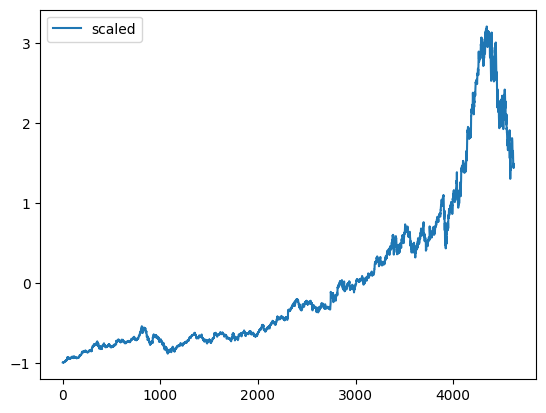

In [11]:
# Visualize scaled data
plt.plot(train['Close'], label = 'scaled')
plt.legend()
plt.show()

**Why This Matters for Stock Prediction**
LSTM/GRU models expect standardized inputs `(0 mean, 1 std)`

Prevents exploding gradients from large price values `(~$100-2000)`

Test data uses train scaler to avoid data leakage

GOOG close prices `(likely $100s-$1000s)` become z-scores like `[-2.1, -1.8, 0.5, 2.3]` after scaling

In [12]:
## 3. Create sequences

"""
Create sequences combining TIME_STEPS contiguous data values from the training data.
TIME_STEP is set 30 as we want our network to have memory of 30 days.
"""



'\nCreate sequences combining TIME_STEPS contiguous data values from the training data.\nTIME_STEP is set 30 as we want our network to have memory of 30 days.\n'

In [13]:
TIME_STEPS=30

def create_sequences(X, y, time_steps=TIME_STEPS):
    X_out, y_out = [], []
    for i in range(len(X)-time_steps):
        X_out.append(X.iloc[i:(i+time_steps)].values)
        y_out.append(y.iloc[i+time_steps])
    
    return np.array(X_out), np.array(y_out)

X_train, y_train = create_sequences(train[['Close']], train['Close'])
X_test, y_test = create_sequences(test[['Close']], test['Close'])
print("Training input shape: ", X_train.shape)
print("Testing input shape: ", X_test.shape)

Training input shape:  (4591, 30, 1)
Testing input shape:  (787, 30, 1)


In [14]:

X_train[3331]

array([[0.39705015],
       [0.3925203 ],
       [0.38922587],
       [0.38958096],
       [0.38235326],
       [0.39881063],
       [0.37976902],
       [0.37876088],
       [0.40163648],
       [0.40372397],
       [0.4103268 ],
       [0.42963841],
       [0.41998255],
       [0.38341831],
       [0.38306333],
       [0.36710304],
       [0.35078734],
       [0.35997452],
       [0.37876088],
       [0.39658136],
       [0.40527179],
       [0.41102234],
       [0.4101421 ],
       [0.4103268 ],
       [0.42245331],
       [0.4438095 ],
       [0.46219795],
       [0.45302508],
       [0.44488863],
       [0.44301456]])

In [15]:
# set seed to regenerate same sequence of random numbers. 
np.random.seed(21)
tf.random.set_seed(21)

In [ ]:
model = Sequential()
model.add(LSTM(64, activation = 'tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(rate=0.3))
model.add(Dense(1))
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
model.summary()


"""
model = Sequential()
model.add(LSTM(128, activation = 'tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(rate=0.2))
model.add(RepeatVector(X_train.shape[1]))
model.add(LSTM(128, activation = 'tanh', return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(TimeDistributed(Dense(X_train.shape[2])))
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
model.summary()
"""
"""I will modify the model by reducing the number of units in the LSTM layers and increasing the dropout rate. 
This should help to reduce the model's complexity and improve its ability to generalize. After these changes,
we'll re-train the model and observe the new loss curves.
"""

c:\Users\samsung\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

"modify the model by reducing the number of units in the LSTM layers and increasing the dropout rate. \nThis should help to reduce the model's complexity and improve its ability to generalize. After these changes,\nwe'll re-train the model and observe the new loss curves.\n"

In [21]:
history = model.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min')],
                    shuffle=False)

Epoch 1/100


130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0593 - val_loss: 0.2964
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0113 - val_loss: 0.0306
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0092 - val_loss: 0.0745
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0080 - val_loss: 0.0594
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0059 - val_loss: 0.0780
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0066 - val_loss: 0.1020
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0072 - val_loss: 0.0897
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0078 - val_loss: 0.0583
Epoch 9/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - val_loss: 0.0683
Epoch 10/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0064 - val_loss: 0.0495
Epoch 11/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0048 - val_loss: 0.0260
Epoch 12/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms

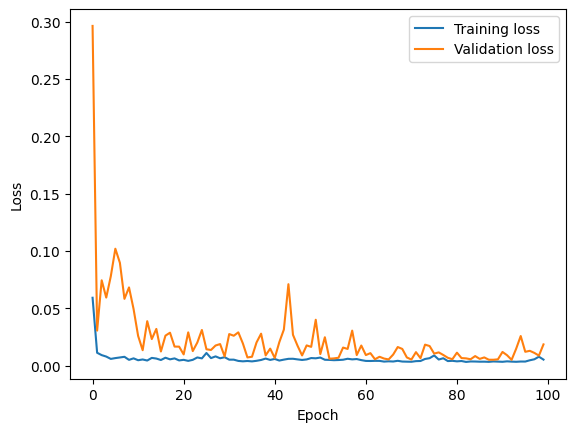

In [22]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();

In [24]:
# Get train predictions and calculate MSE
train_pred = model.predict(X_train)
train_mse = np.abs(train_pred.flatten() - y_train)

# Get test predictions and calculate MSE
test_pred = model.predict(X_test)
test_mse = np.abs(test_pred.flatten() - y_test)

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Reconstruction error threshold: 0.22945438613536778


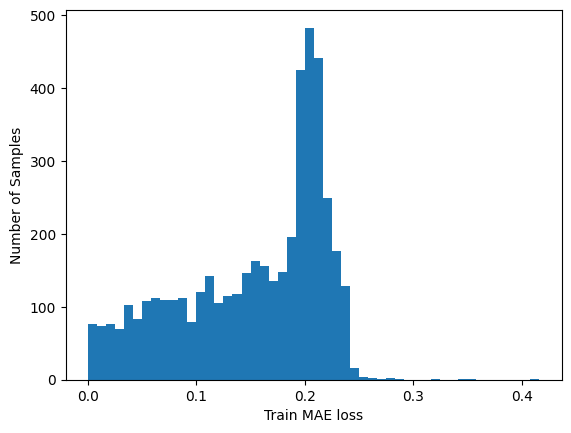

In [28]:
# Mean Absolute Error loss
X_train_pred = model.predict(X_train)
# Calculate MAE between predictions and actual values
train_mae_loss = np.abs(X_train_pred.flatten() - y_train)

plt.hist(train_mae_loss, bins=50)
plt.xlabel('Train MAE loss')
plt.ylabel('Number of Samples');

# Set reconstruction error threshold
threshold = np.percentile(train_mae_loss, 95)  # Use 95th percentile instead of max for better anomaly detection

print('Reconstruction error threshold:',threshold)

## **Reconstruction error threshold: 0.22945438613536778**
# **Predict Anomalies on test data using threshold**

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


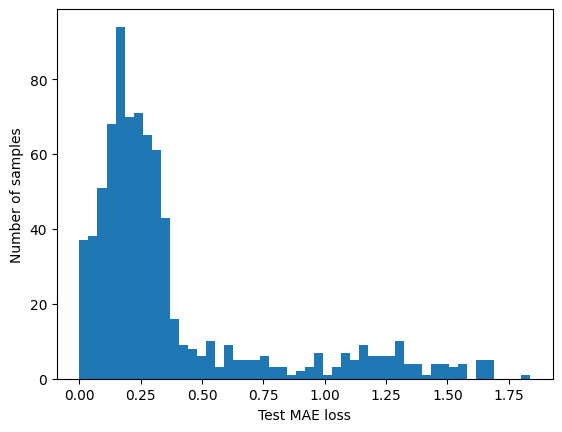

In [30]:
X_test_pred = model.predict(X_test, verbose=1)
test_mae_loss = np.abs(X_test_pred.flatten() - y_test)

plt.hist(test_mae_loss, bins=50)
plt.xlabel('Test MAE loss')
plt.ylabel('Number of samples')
plt.show()

In [31]:
anomaly_df = pd.DataFrame(test[TIME_STEPS:])
anomaly_df['loss'] = test_mae_loss
anomaly_df['threshold'] = threshold
anomaly_df['anomaly'] = anomaly_df['loss'] > anomaly_df['threshold']

In [32]:
anomaly_df.head()

,Date,Close,loss,threshold,anomaly
4651,2023-02-09 00:00:00-05:00,1.643695,0.108530,0.229454,False
4652,2023-02-10 00:00:00-05:00,1.626656,0.044083,0.229454,False
4653,2023-02-13 00:00:00-05:00,1.630632,0.090289,0.229454,False
4654,2023-02-14 00:00:00-05:00,1.629212,0.069796,0.229454,False
4655,2023-02-15 00:00:00-05:00,1.690270,0.113468,0.229454,False


In [33]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=anomaly_df['Date'], y=anomaly_df['loss'], name='Test loss'))
fig.add_trace(go.Scatter(x=anomaly_df['Date'], y=anomaly_df['threshold'], name='Threshold'))
fig.update_layout(showlegend=True, title='Test loss vs. Threshold')
fig.show()

In [34]:
anomalies = anomaly_df.loc[anomaly_df['anomaly'] == True]
anomalies.head()

,Date,Close,loss,threshold,anomaly
4756,2023-07-13 00:00:00-04:00,2.477783,0.259600,0.229454,True
4765,2023-07-26 00:00:00-04:00,2.614953,0.297576,0.229454,True
4785,2023-08-23 00:00:00-04:00,2.715770,0.230657,0.229454,True
4789,2023-08-29 00:00:00-04:00,2.780521,0.244860,0.229454,True
4832,2023-10-30 00:00:00-04:00,2.503911,0.236207,0.229454,True


In [35]:
anomalies.shape

(402, 5)

In [37]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=anomaly_df['Date'], y=scaler.inverse_transform(anomaly_df[['Close']]), name='Close price'))
fig.add_trace(go.Scatter(x=anomalies['Date'], y=scaler.inverse_transform(anomalies[['Close']]), mode='markers', name='Anomaly'))
fig.update_layout(showlegend=True, title='Detected anomalies')
fig.show()